# 정시 도착 주문의 저평점 원인 탐색

## 분석 목적

이 분석은 배송 예정일을 지킨 주문, 즉 정시 도착 주문 중에서도 리뷰점수가 낮게 나타나는 원인을 탐색하는 것을 목적으로 한다.

기존 분석에서 정시 도착 주문이라도 예정 배송기간이나 실제 배송기간이 길 경우 리뷰점수가 낮아지는 패턴이 확인되었다.

따라서 본 분석에서는 정시 도착 주문만 분리한 뒤, 저평점 기준을 세 가지로 나누어 원인을 비교한다.

| 기준 | 의미 |
|---|---|
| 리뷰점수 ≤ 3.0 | 명확한 불만족 |
| 리뷰점수 ≤ 3.5 | 불만족 + 중립권 |
| 리뷰점수 ≤ 4.0 | 5점 이탈, 만족도 저하 신호 |

이를 통해 극단적 불만족 요인과 5점 리뷰를 받지 못하는 요인을 구분한다.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 100)

df = pd.read_csv("../../../data/olist_delivered_item_level_cleaned_errors.csv")

df.shape

(108581, 68)

## 1. 분석용 데이터 생성

현재 데이터는 item level 데이터이므로 하나의 주문이 여러 행으로 반복될 수 있다.

리뷰점수, 배송일, 고객 지역 등은 주문 단위로 해석해야 하므로 `order_id` 기준으로 집계한다.

이후 배송 예정일을 지킨 주문만 필터링한다.

정시 도착 주문은 다음과 같이 정의한다.

`delivery_gap_days <= 0`

즉, 실제 배송일이 배송 예정일보다 늦지 않은 주문이다.

In [2]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df["product_volume_cm3"] = (
    df["product_length_cm"] *
    df["product_height_cm"] *
    df["product_width_cm"]
)

df["freight_ratio"] = df["freight_value"] / df["price"]
df["freight_ratio"] = df["freight_ratio"].replace([np.inf, -np.inf], np.nan)

df["delivery_gap_days"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

df["estimated_delivery_days"] = (
    df["order_estimated_delivery_date"] -
    df["order_purchase_timestamp"]
).dt.total_seconds() / 86400

df["approval_days"] = (
    df["order_approved_at"] -
    df["order_purchase_timestamp"]
).dt.total_seconds() / 86400

df["seller_dispatch_days"] = (
    df["order_delivered_carrier_date"] -
    df["order_approved_at"]
).dt.total_seconds() / 86400

df["carrier_delivery_days"] = (
    df["order_delivered_customer_date"] -
    df["order_delivered_carrier_date"]
).dt.total_seconds() / 86400

df["seller_late_to_carrier"] = (
    df["order_delivered_carrier_date"] >
    df["shipping_limit_date"]
)

df["category"] = df["product_category_name_english"].fillna("unknown")

In [3]:
order_df = df.groupby("order_id", as_index=False).agg(
    review_score_mean=("review_score_mean", "first"),
    
    delivery_gap_days=("delivery_gap_days", "first"),
    delivery_days_clean=("delivery_days_clean", "first"),
    estimated_delivery_days=("estimated_delivery_days", "first"),
    approval_days=("approval_days", "first"),
    seller_dispatch_days=("seller_dispatch_days", "first"),
    carrier_delivery_days=("carrier_delivery_days", "first"),
    seller_late_to_carrier=("seller_late_to_carrier", "first"),
    
    customer_region=("customer_region", "first"),
    customer_state=("customer_state", "first"),
    seller_region=("seller_region", "first"),
    seller_state=("seller_state", "first"),
    delivery_route=("delivery_route", "first"),
    seller_customer_same_state=("seller_customer_same_state", "first"),
    
    payment_value_total=("payment_value_total", "first"),
    payment_installments_max=("payment_installments_max", "first"),
    
    price_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
    avg_freight_ratio=("freight_ratio", "mean"),
    item_count=("order_item_id", "count"),
    
    avg_product_weight_g=("product_weight_g", "mean"),
    avg_product_volume_cm3=("product_volume_cm3", "mean"),
    main_category=("category", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "unknown")
)

order_df = order_df.replace([np.inf, -np.inf], np.nan)

order_df.shape

(95082, 24)

In [4]:
# 정시 도착 주문만 필터링
ontime_df = order_df[
    order_df["delivery_gap_days"] <= 0
].copy()

ontime_df = ontime_df.dropna(subset=[
    "review_score_mean",
    "delivery_days_clean",
    "estimated_delivery_days",
    "seller_dispatch_days",
    "carrier_delivery_days"
]).copy()

ontime_df.shape

(86816, 24)

## 2. 저평점 기준 생성

저평점 기준을 하나만 사용하면 분석 결과가 특정 기준에 의존할 수 있다.

따라서 본 분석에서는 세 가지 기준을 비교한다.

- `low_review_3`: 리뷰점수 3점 이하
- `low_review_35`: 리뷰점수 3.5점 이하
- `low_review_4`: 리뷰점수 4점 이하

이렇게 하면 극단적 불만족 요인과 5점 이탈 요인을 구분할 수 있다.

In [5]:
ontime_df["low_review_3"] = (ontime_df["review_score_mean"] <= 3.0).astype(int)
ontime_df["low_review_35"] = (ontime_df["review_score_mean"] <= 3.5).astype(int)
ontime_df["low_review_4"] = (ontime_df["review_score_mean"] <= 4.0).astype(int)

target_summary = pd.DataFrame({
    "target": ["low_review_3", "low_review_35", "low_review_4"],
    "positive_count": [
        ontime_df["low_review_3"].sum(),
        ontime_df["low_review_35"].sum(),
        ontime_df["low_review_4"].sum()
    ],
    "positive_rate": [
        ontime_df["low_review_3"].mean(),
        ontime_df["low_review_35"].mean(),
        ontime_df["low_review_4"].mean()
    ]
})

target_summary["positive_rate_pct"] = target_summary["positive_rate"] * 100

display(target_summary)

,target,positive_count,positive_rate,positive_rate_pct
0,low_review_3,14963,0.172353,17.235302
1,low_review_35,14984,0.172595,17.259491
2,low_review_4,32639,0.375956,37.595604


C:\Users\yiho1\AppData\Local\Temp\ipykernel_47264\67853128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


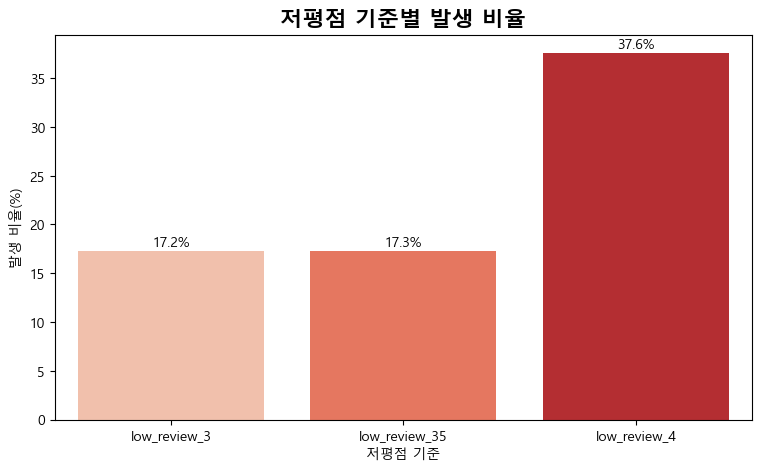

In [6]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=target_summary,
    x="target",
    y="positive_rate_pct",
    palette="Reds"
)

plt.title("저평점 기준별 발생 비율", fontsize=16, weight="bold")
plt.xlabel("저평점 기준")
plt.ylabel("발생 비율(%)")

for i, row in target_summary.iterrows():
    plt.text(
        i,
        row["positive_rate_pct"] + 0.5,
        f'{row["positive_rate_pct"]:.1f}%',
        ha="center"
    )

plt.show()

## 3. 모델링 방향

본 분석의 목적은 예측 성능 자체가 아니라, 정시 도착 주문에서 낮은 리뷰점수가 발생하는 주요 원인을 파악하는 것이다.

따라서 해석 가능한 변수 중요도를 제공하는 Random Forest 모델을 사용한다.

세 개의 저평점 기준에 대해 동일한 입력 변수를 사용하고, 각 기준별 변수 중요도를 비교한다.

이를 통해 다음을 확인한다.

1. 어떤 요인이 모든 저평점 기준에서 공통적으로 중요한가?
2. 어떤 요인이 3점 이하의 극단적 불만족에 더 중요한가?
3. 어떤 요인이 4점 이하, 즉 5점 이탈에 더 중요한가?

In [7]:
numeric_features = [
    "delivery_days_clean",
    "estimated_delivery_days",
    "approval_days",
    "seller_dispatch_days",
    "carrier_delivery_days",
    "payment_value_total",
    "payment_installments_max",
    "price_total",
    "freight_total",
    "avg_freight_ratio",
    "item_count",
    "avg_product_weight_g",
    "avg_product_volume_cm3"
]

categorical_features = [
    "seller_late_to_carrier",
    "customer_region",
    "customer_state",
    "seller_region",
    "seller_state",
    "seller_customer_same_state",
    "main_category"
]

feature_cols = numeric_features + categorical_features

model_df = ontime_df[feature_cols + [
    "low_review_3",
    "low_review_35",
    "low_review_4"
]].dropna().copy()

model_df.shape

(86800, 23)

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

def train_rf_for_target(target_col):
    X = model_df[feature_cols]
    y = model_df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=50,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            ))
        ]
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    
    print("=" * 80)
    print(f"Target: {target_col}")
    print("ROC-AUC:", round(auc, 4))
    print(classification_report(y_test, y_pred))
    
    fitted_preprocessor = model.named_steps["preprocessor"]
    classifier = model.named_steps["classifier"]
    
    feature_names = fitted_preprocessor.get_feature_names_out()
    importances = classifier.feature_importances_
    
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
        "target": target_col
    }).sort_values("importance", ascending=False)
    
    return model, importance_df, auc

In [9]:
models = {}
importance_results = []
auc_results = []

for target in ["low_review_3", "low_review_35", "low_review_4"]:
    model, importance_df, auc = train_rf_for_target(target)
    models[target] = model
    importance_results.append(importance_df)
    auc_results.append({
        "target": target,
        "roc_auc": auc
    })

importance_all = pd.concat(importance_results, ignore_index=True)
auc_df = pd.DataFrame(auc_results)

display(auc_df)

Target: low_review_3
ROC-AUC: 0.6359
              precision    recall  f1-score   support

           0       0.87      0.72      0.79     14368
           1       0.26      0.48      0.34      2992

    accuracy                           0.68     17360
   macro avg       0.57      0.60      0.56     17360
weighted avg       0.76      0.68      0.71     17360

Target: low_review_35
ROC-AUC: 0.6207
              precision    recall  f1-score   support

           0       0.86      0.73      0.79     14364
           1       0.25      0.45      0.32      2996

    accuracy                           0.68     17360
   macro avg       0.56      0.59      0.56     17360
weighted avg       0.76      0.68      0.71     17360

Target: low_review_4
ROC-AUC: 0.5989
              precision    recall  f1-score   support

           0       0.68      0.67      0.67     10833
           1       0.46      0.47      0.47      6527

    accuracy                           0.60     17360
   macro avg    

,target,roc_auc
0,low_review_3,0.635896
1,low_review_35,0.620667
2,low_review_4,0.598874


## 4. 기준별 변수 중요도 확인

각 저평점 기준별로 Random Forest 변수 중요도를 확인한다.

변수 중요도는 해당 변수가 저평점 분류에 얼마나 기여했는지를 나타낸다.

다만 변수 중요도는 인과관계를 의미하지 않는다.  
따라서 중요도가 높은 변수는 추가적인 EDA와 통계검정으로 해석해야 한다.

C:\Users\yiho1\AppData\Local\Temp\ipykernel_47264\2464030275.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


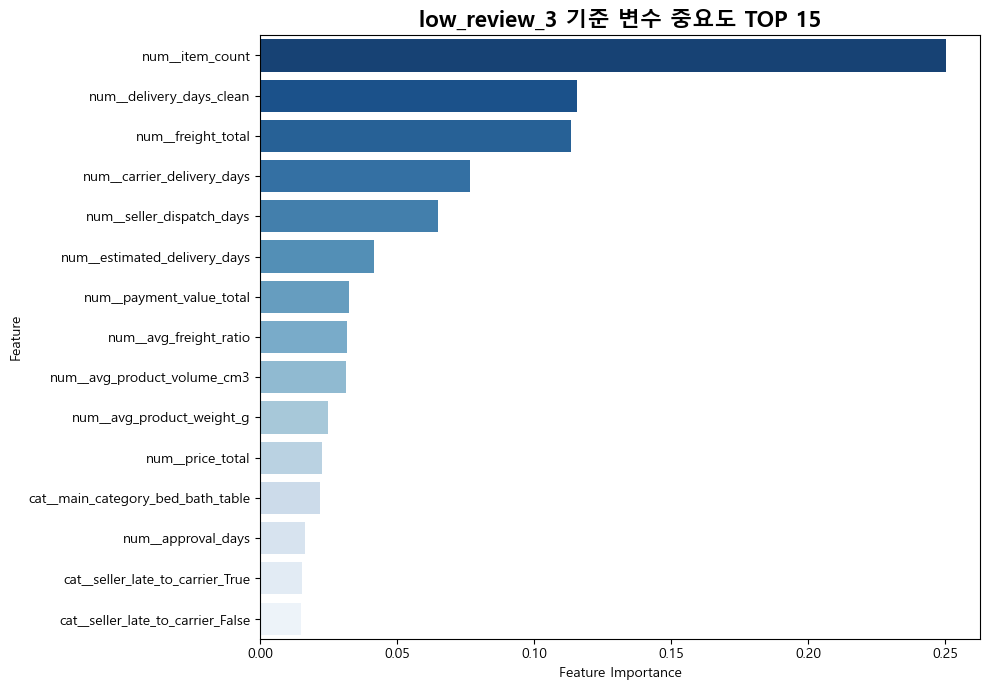

C:\Users\yiho1\AppData\Local\Temp\ipykernel_47264\2464030275.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


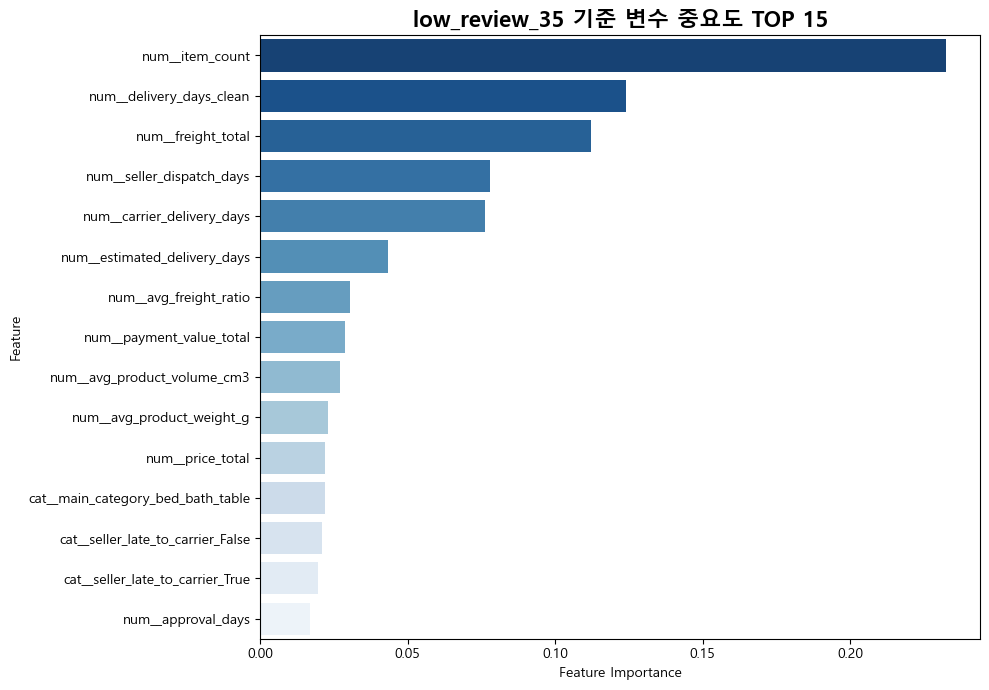

C:\Users\yiho1\AppData\Local\Temp\ipykernel_47264\2464030275.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


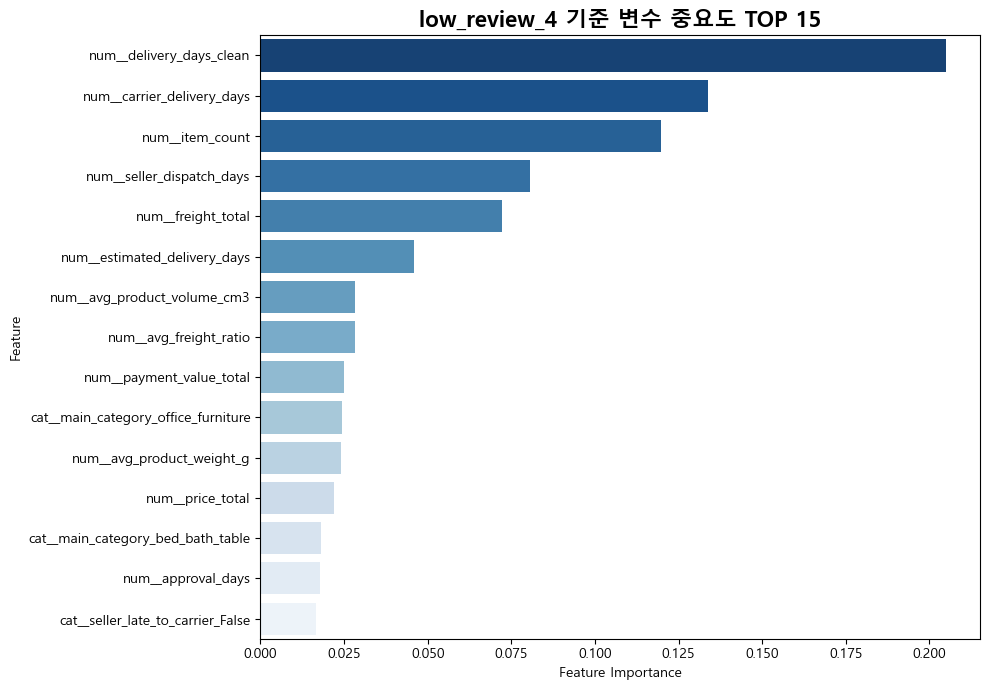

In [11]:
for target in ["low_review_3", "low_review_35", "low_review_4"]:
    top_imp = importance_all[
        importance_all["target"] == target
    ].head(15)
    
    plt.figure(figsize=(10, 7))
    
    sns.barplot(
        data=top_imp,
        y="feature",
        x="importance",
        palette="Blues_r"
    )
    
    plt.title(f"{target} 기준 변수 중요도 TOP 15", fontsize=16, weight="bold")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    
    plt.tight_layout()
    plt.show()

## 5. 변수 중요도 비교

세 기준에서 공통적으로 중요한 변수를 비교한다.

특정 변수가 모든 기준에서 중요하다면, 정시 도착 주문의 전반적인 만족도 저하 요인일 가능성이 있다.

반면 특정 기준에서만 중요하다면, 해당 기준에 특화된 원인으로 해석할 수 있다.

In [12]:
top_n = 20

top_features = importance_all.groupby("target").head(top_n)

importance_pivot = top_features.pivot_table(
    index="feature",
    columns="target",
    values="importance",
    fill_value=0
)

importance_pivot["importance_sum"] = importance_pivot.sum(axis=1)

importance_pivot = importance_pivot.sort_values(
    "importance_sum",
    ascending=False
)

display(importance_pivot.head(30))

target,low_review_3,low_review_35,low_review_4,importance_sum
feature,,,,
num__item_count,0.250169,0.232504,0.119802,0.602475
num__delivery_days_clean,0.115556,0.124127,0.204864,0.444547
num__freight_total,0.113366,0.112183,0.072145,0.297694
num__carrier_delivery_days,0.076607,0.076049,0.133832,0.286488
num__seller_dispatch_days,0.064767,0.077777,0.080647,0.223191
num__estimated_delivery_days,0.041378,0.043391,0.045934,0.130703
num__avg_freight_ratio,0.031529,0.030309,0.028355,0.090193
num__avg_product_volume_cm3,0.031383,0.027114,0.028418,0.086914
num__payment_value_total,0.032468,0.028744,0.025084,0.086296


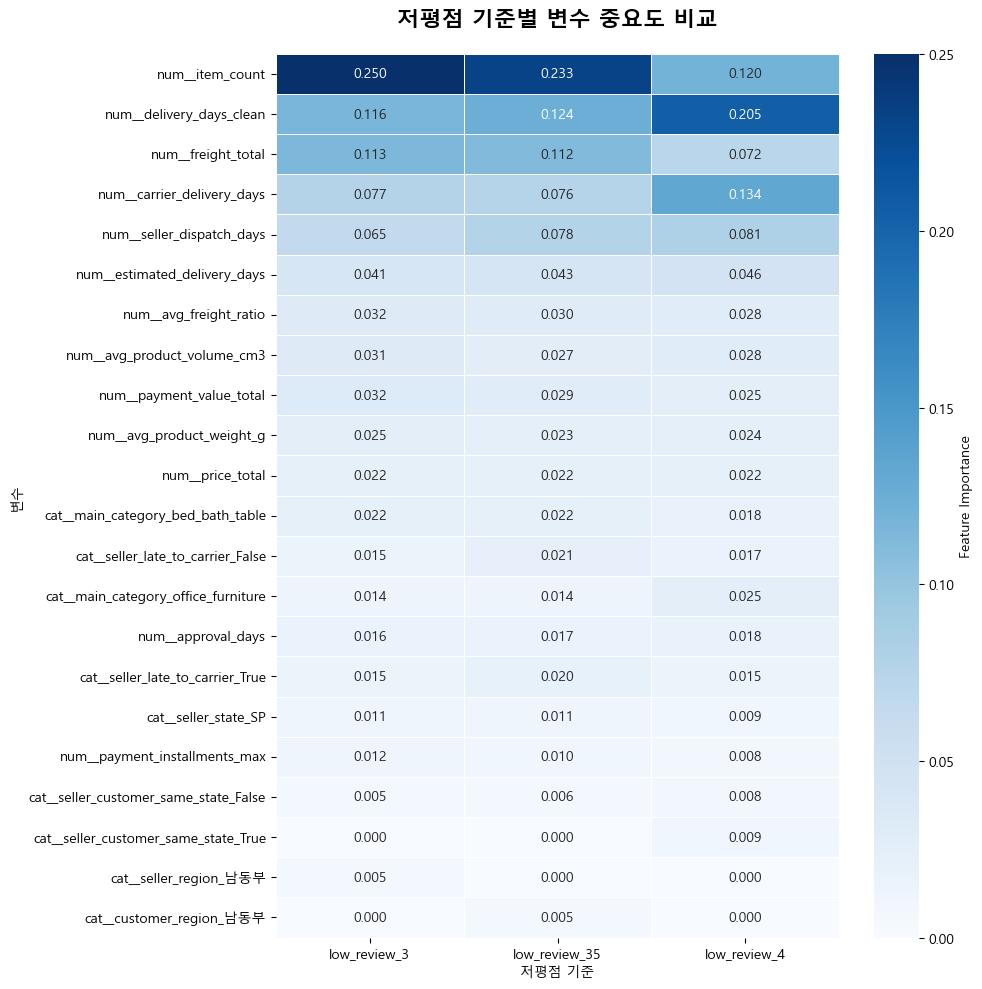

In [13]:
plt.figure(figsize=(10, 10))

sns.heatmap(
    importance_pivot.drop(columns="importance_sum").head(30),
    cmap="Blues",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Feature Importance"}
)

plt.title("저평점 기준별 변수 중요도 비교", fontsize=16, weight="bold", pad=20)
plt.xlabel("저평점 기준")
plt.ylabel("변수")

plt.tight_layout()
plt.show()

## 6. 변수 그룹별 중요도 비교

One-hot encoding으로 인해 카테고리, 지역, 주(state) 변수는 여러 개의 세부 변수로 나뉜다.

따라서 개별 변수 중요도뿐 아니라 변수 그룹별 중요도를 함께 확인한다.

이를 통해 저평점 원인이 배송 리드타임 문제인지, 판매자 처리 문제인지, 지역 문제인지, 카테고리 문제인지 더 명확하게 해석할 수 있다.

In [14]:
def map_feature_group(feature):
    if "delivery_days_clean" in feature:
        return "실제 배송기간"
    if "estimated_delivery_days" in feature:
        return "예정 배송기간"
    if "seller_dispatch_days" in feature or "seller_late_to_carrier" in feature:
        return "판매자 발송 처리"
    if "carrier_delivery_days" in feature:
        return "운송사 배송기간"
    if "approval_days" in feature:
        return "결제 승인 시간"
    if "customer_region" in feature or "customer_state" in feature:
        return "고객 지역"
    if "seller_region" in feature or "seller_state" in feature:
        return "판매자 지역"
    if "seller_customer_same_state" in feature:
        return "동일 주 여부"
    if "main_category" in feature:
        return "상품 카테고리"
    if "freight" in feature:
        return "배송비 부담"
    if "price_total" in feature or "payment_value_total" in feature:
        return "주문금액"
    if "product_weight" in feature or "product_volume" in feature:
        return "상품 물리 특성"
    if "item_count" in feature:
        return "상품 개수"
    if "payment_installments" in feature:
        return "할부 개월"
    return "기타"

importance_all["feature_group"] = importance_all["feature"].apply(map_feature_group)

group_importance = importance_all.groupby(
    ["target", "feature_group"],
    as_index=False
)["importance"].sum()

group_pivot = group_importance.pivot_table(
    index="feature_group",
    columns="target",
    values="importance",
    fill_value=0
)

group_pivot["importance_sum"] = group_pivot.sum(axis=1)
group_pivot = group_pivot.sort_values("importance_sum", ascending=False)

display(group_pivot)

target,low_review_3,low_review_35,low_review_4,importance_sum
feature_group,,,,
상품 개수,0.250169,0.232504,0.119802,0.602475
실제 배송기간,0.115556,0.124127,0.204864,0.444547
배송비 부담,0.144895,0.142492,0.100500,0.387887
판매자 발송 처리,0.094900,0.118229,0.112092,0.325222
운송사 배송기간,0.076607,0.076049,0.133832,0.286488
상품 카테고리,0.069295,0.070462,0.083763,0.223520
상품 물리 특성,0.056120,0.050188,0.052543,0.158851
주문금액,0.054772,0.050827,0.047233,0.152832
예정 배송기간,0.041378,0.043391,0.045934,0.130703


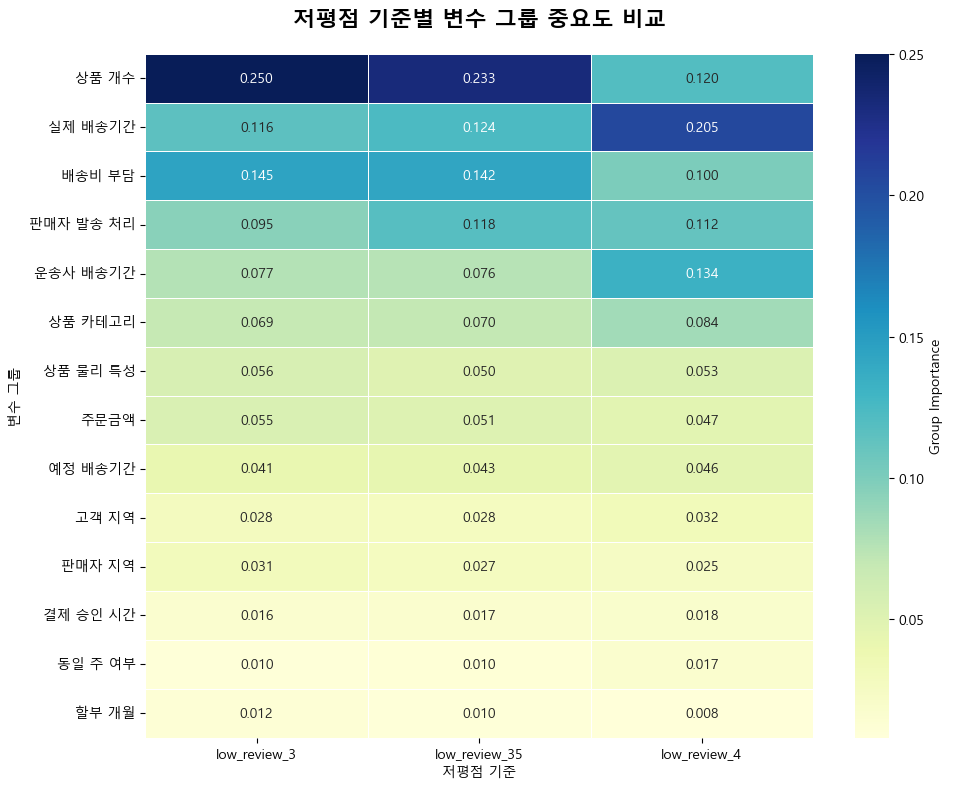

In [15]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    group_pivot.drop(columns="importance_sum"),
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Group Importance"}
)

plt.title("저평점 기준별 변수 그룹 중요도 비교", fontsize=16, weight="bold", pad=20)
plt.xlabel("저평점 기준")
plt.ylabel("변수 그룹")

plt.tight_layout()
plt.show()

## 7. 주요 변수별 실제 리뷰점수 비교

머신러닝 변수 중요도는 원인 후보를 찾는 데 유용하지만, 실제 차이를 함께 확인해야 한다.

따라서 중요도가 높게 나타난 주요 변수에 대해 리뷰점수와 저평점 비율을 비교한다.

In [16]:
# 예정 배송기간 구간화
ontime_df["estimated_days_bin"] = pd.cut(
    ontime_df["estimated_delivery_days"],
    bins=[0, 7, 14, 21, 30, np.inf],
    labels=["~7일", "8~14일", "15~21일", "22~30일", "30일 초과"],
    right=True
)

estimated_summary = ontime_df.groupby("estimated_days_bin", observed=True).agg(
    order_count=("order_id", "count"),
    avg_review_score=("review_score_mean", "mean"),
    low_3_rate=("low_review_3", "mean"),
    low_35_rate=("low_review_35", "mean"),
    low_4_rate=("low_review_4", "mean")
)

display(estimated_summary)

,order_count,avg_review_score,low_3_rate,low_35_rate,low_4_rate
estimated_days_bin,,,,,
~7일,849,4.554770,0.095406,0.095406,0.274441
8~14일,9798,4.400796,0.141253,0.141355,0.332619
15~21일,20744,4.340645,0.158214,0.158359,0.356489
22~30일,37027,4.288074,0.174818,0.175034,0.379966
30일 초과,18398,4.183326,0.203446,0.203935,0.417600


C:\Users\yiho1\AppData\Local\Temp\ipykernel_47264\158411322.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


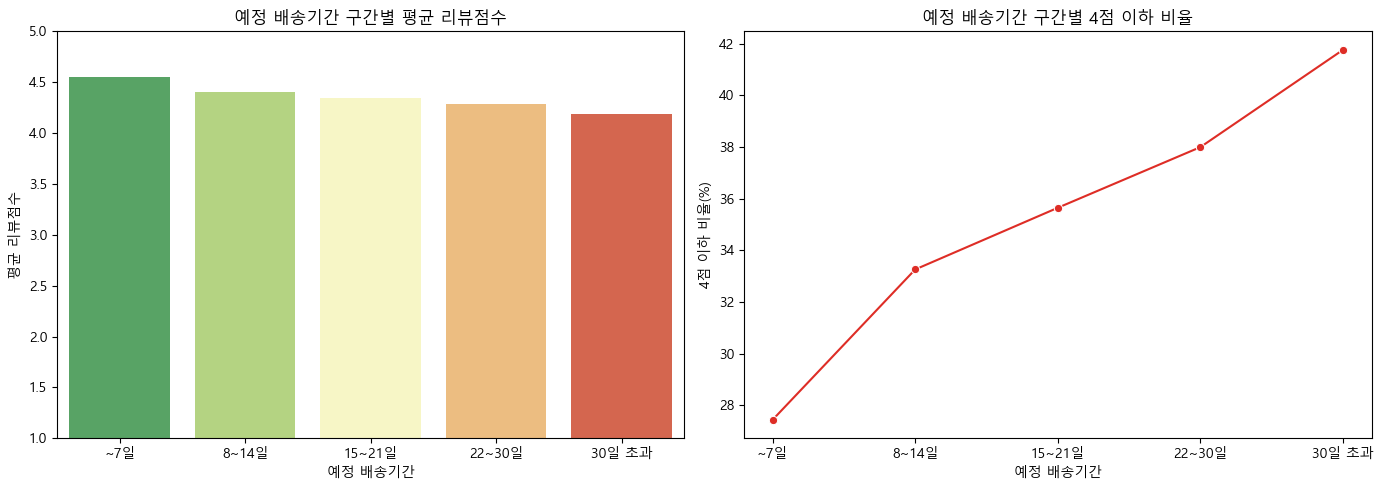

In [17]:
plot_df = estimated_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=plot_df,
    x="estimated_days_bin",
    y="avg_review_score",
    palette="RdYlGn_r",
    ax=axes[0]
)

axes[0].set_title("예정 배송기간 구간별 평균 리뷰점수")
axes[0].set_xlabel("예정 배송기간")
axes[0].set_ylabel("평균 리뷰점수")
axes[0].set_ylim(1, 5)

sns.lineplot(
    data=plot_df,
    x="estimated_days_bin",
    y=plot_df["low_4_rate"] * 100,
    marker="o",
    color="#de2d26",
    ax=axes[1]
)

axes[1].set_title("예정 배송기간 구간별 4점 이하 비율")
axes[1].set_xlabel("예정 배송기간")
axes[1].set_ylabel("4점 이하 비율(%)")

plt.tight_layout()
plt.show()

In [18]:
# 판매자 발송 지연 여부별 비교
seller_late_summary = ontime_df.groupby("seller_late_to_carrier").agg(
    order_count=("order_id", "count"),
    avg_review_score=("review_score_mean", "mean"),
    low_3_rate=("low_review_3", "mean"),
    low_35_rate=("low_review_35", "mean"),
    low_4_rate=("low_review_4", "mean")
)

display(seller_late_summary)

,order_count,avg_review_score,low_3_rate,low_35_rate,low_4_rate
seller_late_to_carrier,,,,,
False,80304,4.311294,0.16714,0.167376,0.369832
True,6512,4.077626,0.23664,0.236947,0.451474


C:\Users\yiho1\AppData\Local\Temp\ipykernel_47264\451947049.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


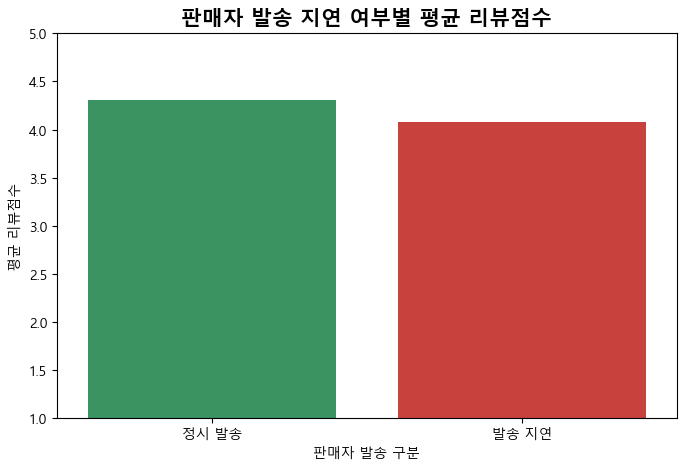

In [19]:
plot_df = seller_late_summary.reset_index()
plot_df["seller_late_label"] = plot_df["seller_late_to_carrier"].map({
    False: "정시 발송",
    True: "발송 지연"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_df,
    x="seller_late_label",
    y="avg_review_score",
    palette=["#2ca25f", "#de2d26"]
)

plt.title("판매자 발송 지연 여부별 평균 리뷰점수", fontsize=15, weight="bold")
plt.xlabel("판매자 발송 구분")
plt.ylabel("평균 리뷰점수")
plt.ylim(1, 5)

plt.show()

## 8. 결과 해석 프레임

모델 결과는 다음 기준으로 해석한다.

| 결과 패턴 | 해석 |
|---|---|
| 예정 배송기간 중요도가 높음 | 고객은 정시 도착 여부뿐 아니라 애초에 오래 기다리는 것에 불만을 가질 수 있음 |
| 실제 배송기간 중요도가 높음 | 실제 대기시간 자체가 고객 만족도에 영향 |
| 판매자 발송 처리 중요도가 높음 | 최종 정시 도착이어도 초기 처리 지연이 부정적 경험으로 작용 가능 |
| 운송사 배송기간 중요도가 높음 | 운송 단계의 긴 리드타임이 저평점 원인 가능 |
| 고객 지역 중요도가 높음 | 특정 지역 고객의 배송 경험 또는 기대 수준 차이 가능 |
| 상품 카테고리 중요도가 높음 | 특정 카테고리의 품질, 파손, 기대치, 물류 난이도 문제 가능 |
| 배송비 부담 중요도가 높음 | 높은 배송비 대비 배송 경험이 만족스럽지 않을 가능성 |

# 최종 해석 예시

정시 도착 주문만을 대상으로 3점 이하, 3.5점 이하, 4점 이하 세 가지 저평점 기준을 설정하고 Random Forest 모델을 학습하였다.

분석 목적은 예측 성능 자체가 아니라, 정시 도착임에도 낮은 평점이 발생하는 주요 요인을 탐색하는 것이다.

세 기준의 변수 중요도를 비교함으로써 극단적 불만족 요인과 5점 이탈 요인을 구분할 수 있었다.

만약 3점 이하 기준에서 판매자 발송 처리나 운송사 배송기간의 중요도가 높게 나타난다면, 이는 명확한 불만족이 배송 처리 과정의 문제와 관련될 가능성을 시사한다.

반면 4점 이하 기준에서 예정 배송기간, 실제 배송기간, 카테고리, 지역 변수의 중요도가 높게 나타난다면, 이는 고객이 최종적으로 정시 도착했더라도 긴 대기시간, 특정 상품군, 특정 지역 배송 경험 때문에 최고점인 5점을 주지 않았을 가능성을 의미한다.

따라서 정시 도착 주문의 낮은 평점은 단일 원인으로 보기 어렵고, 배송 리드타임, 판매자 처리, 지역, 카테고리 요인이 복합적으로 작용한 결과로 해석할 수 있다.

이 결과는 물류 전략 수립에서 중요한 시사점을 제공한다.

1. 정시율만 관리하는 것은 충분하지 않다.
2. 고객에게 제시되는 예정 배송기간 자체를 줄여야 한다.
3. 판매자 발송 처리 지연을 줄이는 운영 관리가 필요하다.
4. 저평점 위험이 높은 지역과 카테고리는 별도로 관리해야 한다.
5. 수요가 많고 저평점 위험이 높은 카테고리는 주요 지역 창고에 사전 배치하는 전략을 검토할 수 있다.

----

# 정시 도착 주문 내 판매자 발송 지연 원인 탐색

## 분석 목적

정시 도착 주문 중에서도 다음 두 집단의 평균 리뷰점수 차이가 확인되었다.

| 구분 | 평균 리뷰점수 |
|---|---:|
| 판매자 정시 발송 + 정시 도착 | 4.02점 |
| 판매자 지각 후 만회 + 정시 도착 | 3.88점 |

두 집단 모두 최종적으로는 배송 예정일을 지켰지만, 판매자가 운송사에 상품을 넘기는 시점에서 차이가 있었다.

본 분석의 목적은 두 집단의 점수 차이가 다음 중 무엇 때문인지 탐색하는 것이다.

1. 판매자 발송 지연 자체의 영향
2. 원래 배송기간이 긴 지역 또는 route의 영향
3. 특정 카테고리 또는 상품 특성의 영향
4. 다품목 주문, 배송비 부담 등 주문 구조의 영향

이를 위해 두 단계의 머신러닝 분석을 수행한다.

- 모델 1: 판매자 발송 지연 변수를 제외하고, 지역/카테고리/배송 리드타임만으로 점수 차이가 설명되는지 확인
- 모델 2: 판매자 발송 지연 변수를 포함하여, 판매자 처리 요인이 얼마나 중요한지 확인

In [21]:
import pandas as pd
import numpy as np

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 100)

df = pd.read_csv("../../../data/olist_delivered_item_level_cleaned_errors.csv")

df.shape

(108581, 68)

## 1. 분석용 데이터 생성

두 집단을 비교하기 위해 배송 예정일을 지킨 주문만 사용한다.

정시 도착은 다음과 같이 정의한다.

`delivery_gap_days <= 0`

판매자 발송 지연은 다음과 같이 정의한다.

`order_delivered_carrier_date > shipping_limit_date`

즉, 판매자가 약속된 발송 제한일보다 늦게 운송사에 상품을 넘긴 경우이다.

In [22]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["delivery_gap_days"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

df["delivery_gap_days"] = np.floor(df["delivery_gap_days"])

df["estimated_delivery_days"] = (
    df["order_estimated_delivery_date"] -
    df["order_purchase_timestamp"]
).dt.total_seconds() / 86400

df["seller_dispatch_days"] = (
    df["order_delivered_carrier_date"] -
    df["order_approved_at"]
).dt.total_seconds() / 86400

df["carrier_delivery_days"] = (
    df["order_delivered_customer_date"] -
    df["order_delivered_carrier_date"]
).dt.total_seconds() / 86400

df["seller_late_to_carrier"] = (
    df["order_delivered_carrier_date"] >
    df["shipping_limit_date"]
)

df["product_volume_cm3"] = (
    df["product_length_cm"] *
    df["product_height_cm"] *
    df["product_width_cm"]
)

df["freight_ratio"] = df["freight_value"] / df["price"]
df["freight_ratio"] = df["freight_ratio"].replace([np.inf, -np.inf], np.nan)

df["category"] = df["product_category_name_english"].fillna("unknown")

In [23]:
order_df = df.groupby("order_id", as_index=False).agg(
    review_score_mean=("review_score_mean", "first"),
    
    delivery_gap_days=("delivery_gap_days", "first"),
    delivery_days_clean=("delivery_days_clean", "first"),
    estimated_delivery_days=("estimated_delivery_days", "first"),
    seller_dispatch_days=("seller_dispatch_days", "first"),
    carrier_delivery_days=("carrier_delivery_days", "first"),
    seller_late_to_carrier=("seller_late_to_carrier", "first"),
    
    customer_region=("customer_region", "first"),
    customer_state=("customer_state", "first"),
    seller_region=("seller_region", "first"),
    seller_state=("seller_state", "first"),
    delivery_route=("delivery_route", "first"),
    seller_customer_same_state=("seller_customer_same_state", "first"),
    
    payment_value_total=("payment_value_total", "first"),
    price_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
    avg_freight_ratio=("freight_ratio", "mean"),
    item_count=("order_item_id", "count"),
    
    avg_product_weight_g=("product_weight_g", "mean"),
    avg_product_volume_cm3=("product_volume_cm3", "mean"),
    main_category=("category", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "unknown")
)

order_df = order_df.replace([np.inf, -np.inf], np.nan)

# 정시 도착 주문만 사용
ontime_df = order_df[
    order_df["delivery_gap_days"] <= 0
].copy()

ontime_df = ontime_df.dropna(subset=[
    "review_score_mean",
    "seller_late_to_carrier",
    "delivery_days_clean",
    "estimated_delivery_days",
    "seller_dispatch_days",
    "carrier_delivery_days"
]).copy()

ontime_df["seller_case"] = np.where(
    ontime_df["seller_late_to_carrier"],
    "판매자 지각 후 만회 + 정시 도착",
    "판매자 정시 발송 + 정시 도착"
)

ontime_df.shape

(88087, 23)

## 2. 두 집단의 리뷰점수 차이 확인

먼저 두 집단의 평균 리뷰점수 차이가 실제로 존재하는지 확인한다.

리뷰점수는 1~5점의 순서형 변수이므로 Mann-Whitney U test를 함께 사용한다.

In [24]:
case_summary = ontime_df.groupby("seller_case").agg(
    order_count=("order_id", "count"),
    avg_review_score=("review_score_mean", "mean"),
    median_review_score=("review_score_mean", "median"),
    avg_delivery_days=("delivery_days_clean", "mean"),
    avg_estimated_days=("estimated_delivery_days", "mean"),
    avg_seller_dispatch_days=("seller_dispatch_days", "mean"),
    avg_carrier_delivery_days=("carrier_delivery_days", "mean"),
    avg_item_count=("item_count", "mean"),
    avg_freight_ratio=("avg_freight_ratio", "mean")
)

display(case_summary)

,order_count,avg_review_score,median_review_score,avg_delivery_days,avg_estimated_days,avg_seller_dispatch_days,avg_carrier_delivery_days,avg_item_count,avg_freight_ratio
seller_case,,,,,,,,,
판매자 정시 발송 + 정시 도착,81263,4.308316,5.0,10.137332,23.669102,2.184675,8.026223,1.140138,0.308382
판매자 지각 후 만회 + 정시 도착,6824,4.072318,5.0,15.818435,25.623618,8.186389,7.665531,1.180393,0.308915


In [26]:
score_ontime_seller = ontime_df.loc[
    ontime_df["seller_case"] == "판매자 정시 발송 + 정시 도착",
    "review_score_mean"
].dropna()

score_late_recovered = ontime_df.loc[
    ontime_df["seller_case"] == "판매자 지각 후 만회 + 정시 도착",
    "review_score_mean"
].dropna()

mw_result = stats.mannwhitneyu(
    score_ontime_seller,
    score_late_recovered,
    alternative="two-sided"
)

print("판매자 정시 발송 + 정시 도착 평균:", score_ontime_seller.mean())
print("판매자 지각 후 만회 + 정시 도착 평균:", score_late_recovered.mean())
print("Mann-Whitney U:", mw_result)

판매자 정시 발송 + 정시 도착 평균: 4.3083157976774995
판매자 지각 후 만회 + 정시 도착 평균: 4.0723182883939035
Mann-Whitney U: MannwhitneyuResult(statistic=np.float64(304146695.5), pvalue=np.float64(2.284761981702481e-53))


C:\Users\yiho1\AppData\Local\Temp\ipykernel_47264\1672341417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


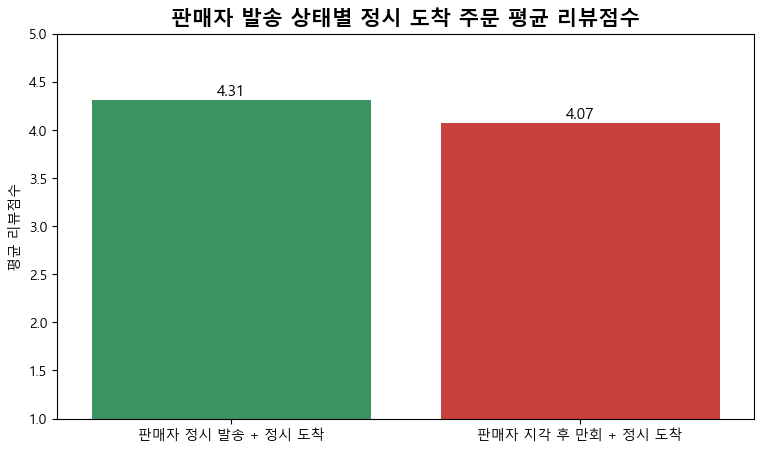

In [27]:
plt.figure(figsize=(9, 5))

plot_df = case_summary.reset_index()

sns.barplot(
    data=plot_df,
    x="seller_case",
    y="avg_review_score",
    palette=["#2ca25f", "#de2d26"]
)

plt.title("판매자 발송 상태별 정시 도착 주문 평균 리뷰점수", fontsize=15, weight="bold")
plt.xlabel("")
plt.ylabel("평균 리뷰점수")
plt.ylim(1, 5)

for i, row in plot_df.iterrows():
    plt.text(
        i,
        row["avg_review_score"] + 0.05,
        f'{row["avg_review_score"]:.2f}',
        ha="center",
        fontsize=11
    )

plt.xticks(rotation=0)
plt.show()

## 해석 기준

두 집단의 평균 리뷰점수 차이가 통계적으로 유의하다면, 최종 정시 도착 여부만으로 고객 만족도를 설명하기 어렵다는 의미이다.

즉, 고객은 최종 도착일뿐 아니라 판매자 처리 과정, 실제 배송기간, 배송비 부담, 상품 구성 등의 요인에도 영향을 받을 수 있다.

# 3. 모델 1: 판매자 지연 변수 없이 점수 차이를 설명할 수 있는가?

## 분석 목적

먼저 판매자 발송 지연 변수를 제외하고 모델을 학습한다.

이 모델은 다음 질문에 답하기 위한 것이다.

> 두 집단의 점수 차이가 판매자 지연 자체 때문이 아니라, 원래 배송기간이 긴 지역, 특정 카테고리, 다품목 주문, 배송비 부담 때문인가?

만약 판매자 지연 변수를 제외한 모델에서도 두 집단의 예측 점수 차이가 크게 나타난다면, 점수 차이의 상당 부분은 지역, 카테고리, 배송 리드타임, 주문 특성의 차이로 설명될 수 있다.

반대로 예측 점수 차이가 작고 실제 점수 차이가 더 크다면, 판매자 발송 지연 자체 또는 데이터에 없는 판매자 처리 경험이 부정적으로 작용했을 가능성이 있다.

In [32]:
numeric_features_context = [
    "delivery_days_clean",
    "estimated_delivery_days",
    "carrier_delivery_days",
    "payment_value_total",
    "price_total",
    "freight_total",
    "avg_freight_ratio",
    "item_count",
    "avg_product_weight_g",
    "avg_product_volume_cm3"
]

categorical_features_context = [
    "customer_region",
    "customer_state",
    "seller_region",
    "seller_state",
    "delivery_route",
    "seller_customer_same_state",
    "main_category"
]

context_feature_cols = numeric_features_context + categorical_features_context

context_model_df = ontime_df[
    context_feature_cols + ["review_score_mean", "seller_case"]
].copy()

context_model_df = context_model_df.dropna(subset=["review_score_mean"]).copy()

# 범주형 변수는 문자열로 변환 후 결측치를 명시적으로 처리
for col in categorical_features_context:
    context_model_df[col] = context_model_df[col].astype("string").fillna("unknown")

# 수치형 변수는 숫자형으로 변환
for col in numeric_features_context:
    context_model_df[col] = pd.to_numeric(context_model_df[col], errors="coerce")

X = context_model_df[context_feature_cols]
y = context_model_df["review_score_mean"]

X_train_context, X_test_context, y_train_context, y_test_context = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

cat_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

context_preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numeric_features_context),
        ("cat", cat_transformer, categorical_features_context)
    ]
)

context_model = Pipeline(
    steps=[
        ("preprocessor", context_preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=50,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

context_model.fit(X_train_context, y_train_context)

context_pred = context_model.predict(X_test_context)

context_mae = mean_absolute_error(y_test_context, context_pred)
context_mse = mean_squared_error(y_test_context, context_pred)
context_rmse = np.sqrt(context_mse)
context_r2 = r2_score(y_test_context, context_pred)

print("MAE:", context_mae)
print("RMSE:", context_rmse)
print("R2:", context_r2)

MAE: 0.8517488211021447
RMSE: 1.1157429145711886
R2: 0.05646426698227869


In [33]:
# 판매자 발송 지연 변수를 제외한 모델이 예측한 점수 차이

context_model_df["pred_context_score"] = context_model.predict(
    context_model_df[context_feature_cols]
)

context_effect_summary = context_model_df.groupby("seller_case").agg(
    actual_score=("review_score_mean", "mean"),
    predicted_by_context=("pred_context_score", "mean"),
    order_count=("review_score_mean", "count")
)

display(context_effect_summary)

actual_diff = (
    context_effect_summary.loc["판매자 지각 후 만회 + 정시 도착", "actual_score"] -
    context_effect_summary.loc["판매자 정시 발송 + 정시 도착", "actual_score"]
)

predicted_context_diff = (
    context_effect_summary.loc["판매자 지각 후 만회 + 정시 도착", "predicted_by_context"] -
    context_effect_summary.loc["판매자 정시 발송 + 정시 도착", "predicted_by_context"]
)

unexplained_diff = actual_diff - predicted_context_diff

print("실제 평균 점수 차이:", actual_diff)
print("지역/카테고리/리드타임으로 설명되는 예측 점수 차이:", predicted_context_diff)
print("남는 차이:", unexplained_diff)

,actual_score,predicted_by_context,order_count
seller_case,,,
판매자 정시 발송 + 정시 도착,4.308316,4.305456,81263
판매자 지각 후 만회 + 정시 도착,4.072318,4.125291,6824


실제 평균 점수 차이: -0.23599750928359686
지역/카테고리/리드타임으로 설명되는 예측 점수 차이: -0.1801652687032016
남는 차이: -0.055832240580395265


## 해석 기준

- 실제 점수 차이와 예측 점수 차이가 비슷하다면  
  → 두 집단의 차이는 지역, 카테고리, 배송 리드타임, 주문 특성 차이로 상당 부분 설명된다.

- 실제 점수 차이가 예측 점수 차이보다 더 크다면  
  → 판매자 발송 지연 자체 또는 데이터에 없는 판매자 처리 경험이 추가적으로 영향을 줬을 가능성이 있다.

이 분석은 인과분석은 아니지만, 두 집단의 점수 차이가 단순 구성 차이 때문인지 확인하는 탐색적 방법이다.

# 4. 모델 2: 판매자 발송 처리 변수를 포함한 원인 탐색 모델

## 분석 목적

이번에는 판매자 발송 처리 변수를 포함하여 리뷰점수를 예측한다.

포함하는 판매자 관련 변수는 다음과 같다.

- `seller_dispatch_days`: 승인 후 운송사 인계까지 걸린 시간
- `seller_late_to_carrier`: 판매자가 발송 제한일보다 늦게 발송했는지 여부

이를 통해 판매자 처리 요인이 리뷰점수 예측에서 얼마나 중요한지 확인한다.

In [34]:
numeric_features_full = [
    "delivery_days_clean",
    "estimated_delivery_days",
    "seller_dispatch_days",
    "carrier_delivery_days",
    "payment_value_total",
    "price_total",
    "freight_total",
    "avg_freight_ratio",
    "item_count",
    "avg_product_weight_g",
    "avg_product_volume_cm3"
]

categorical_features_full = [
    "seller_late_to_carrier",
    "customer_region",
    "customer_state",
    "seller_region",
    "seller_state",
    "delivery_route",
    "seller_customer_same_state",
    "main_category"
]

full_feature_cols = numeric_features_full + categorical_features_full

full_model_df = ontime_df[
    full_feature_cols + ["review_score_mean", "seller_case"]
].copy()

full_model_df = full_model_df.dropna(subset=["review_score_mean"]).copy()

# 범주형 변수 처리
for col in categorical_features_full:
    full_model_df[col] = full_model_df[col].astype("string").fillna("unknown")

# 수치형 변수 처리
for col in numeric_features_full:
    full_model_df[col] = pd.to_numeric(full_model_df[col], errors="coerce")

X = full_model_df[full_feature_cols]
y = full_model_df["review_score_mean"]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

full_preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numeric_features_full),
        ("cat", cat_transformer, categorical_features_full)
    ]
)

full_model = Pipeline(
    steps=[
        ("preprocessor", full_preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=50,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

full_model.fit(X_train_full, y_train_full)

full_pred = full_model.predict(X_test_full)

full_mae = mean_absolute_error(y_test_full, full_pred)
full_mse = mean_squared_error(y_test_full, full_pred)
full_rmse = np.sqrt(full_mse)
full_r2 = r2_score(y_test_full, full_pred)

print("MAE:", full_mae)
print("RMSE:", full_rmse)
print("R2:", full_r2)

MAE: 0.8517436325025959
RMSE: 1.115855135110243
R2: 0.05627445728317593


In [35]:
# 모델 1과 모델 2 성능 비교

model_compare = pd.DataFrame({
    "model": [
        "모델 1: 판매자 발송 변수 제외",
        "모델 2: 판매자 발송 변수 포함"
    ],
    "MAE": [
        context_mae,
        full_mae
    ],
    "RMSE": [
        context_rmse,
        full_rmse
    ],
    "R2": [
        context_r2,
        full_r2
    ]
})

display(model_compare)

,model,MAE,RMSE,R2
0,모델 1: 판매자 발송 변수 제외,0.851749,1.115743,0.056464
1,모델 2: 판매자 발송 변수 포함,0.851744,1.115855,0.056274


## 해석 기준

모델 2의 MAE와 RMSE가 모델 1보다 낮고, R2가 높다면 판매자 발송 처리 변수가 리뷰점수 설명에 추가적인 정보를 제공한다고 해석할 수 있다.

반대로 두 모델의 성능 차이가 거의 없다면, 판매자 발송 지연 자체보다는 배송 리드타임, 지역, 카테고리, 주문 특성 차이가 더 큰 설명 요인일 수 있다.

# 5. 변수 중요도 분석

## 분석 목적

모델 2에서 어떤 변수가 리뷰점수 예측에 중요했는지 확인한다.

특히 판매자 발송 처리 변수가 주요 변수로 나타나는지 확인한다.

In [36]:
perm_result = permutation_importance(
    full_model,
    X_test_full,
    y_test_full,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "feature": full_feature_cols,
    "importance": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance", ascending=False)

display(importance_df)

,feature,importance,importance_std
0,delivery_days_clean,0.024985,0.000738
8,item_count,0.019760,0.000940
2,seller_dispatch_days,0.004631,0.000397
3,carrier_delivery_days,0.002718,0.000143
1,estimated_delivery_days,0.002337,0.000208
12,customer_region,0.001659,0.000280
10,avg_product_volume_cm3,0.001446,0.000262
18,main_category,0.001004,0.000189
7,avg_freight_ratio,0.000680,0.000093
4,payment_value_total,0.000461,0.000046


C:\Users\yiho1\AppData\Local\Temp\ipykernel_47264\66472144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


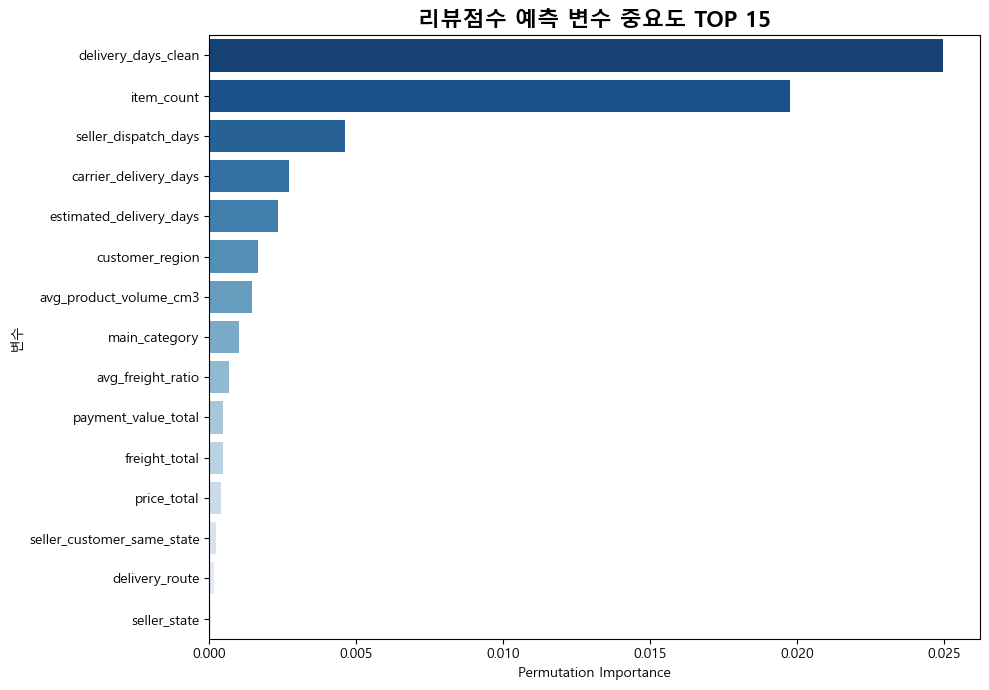

In [37]:
top_imp = importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_imp,
    y="feature",
    x="importance",
    palette="Blues_r"
)

plt.title("리뷰점수 예측 변수 중요도 TOP 15", fontsize=16, weight="bold")
plt.xlabel("Permutation Importance")
plt.ylabel("변수")

plt.tight_layout()
plt.show()

## 해석 기준

Permutation Importance는 특정 변수를 무작위로 섞었을 때 모델 성능이 얼마나 나빠지는지를 나타낸다.

따라서 중요도가 높은 변수는 리뷰점수 예측에 중요한 역할을 했다고 볼 수 있다.

- `seller_dispatch_days` 중요도가 높음  
  → 판매자 처리 시간이 리뷰점수 차이에 영향을 줬을 가능성

- `seller_late_to_carrier` 중요도가 높음  
  → 판매자 발송 지연 여부 자체가 리뷰점수 차이에 영향을 줬을 가능성

- `delivery_days_clean`, `carrier_delivery_days` 중요도가 높음  
  → 최종 정시 도착이어도 실제 배송 리드타임이 중요

- `main_category` 중요도가 높음  
  → 특정 카테고리의 품질, 배송 난이도, 기대 수준 차이 가능

- `customer_region`, `delivery_route` 중요도가 높음  
  → 특정 지역 또는 route의 구조적 배송 경험 차이 가능

# 6. 변수 그룹별 중요도 해석

## 분석 목적

개별 변수만 보면 해석이 복잡할 수 있으므로 변수를 그룹으로 묶어 중요도를 확인한다.

이를 통해 원인이 판매자 처리 문제인지, 지역 문제인지, 카테고리 문제인지, 리드타임 문제인지 더 명확하게 볼 수 있다.

In [38]:
def feature_group(feature):
    if feature in ["seller_dispatch_days", "seller_late_to_carrier"]:
        return "판매자 발송 처리"
    if feature in ["delivery_days_clean", "estimated_delivery_days", "carrier_delivery_days"]:
        return "배송 리드타임"
    if feature in ["customer_region", "customer_state"]:
        return "고객 지역"
    if feature in ["seller_region", "seller_state", "delivery_route", "seller_customer_same_state"]:
        return "출고지/route"
    if feature == "main_category":
        return "상품 카테고리"
    if feature in ["freight_total", "avg_freight_ratio"]:
        return "배송비 부담"
    if feature in ["price_total", "payment_value_total"]:
        return "주문금액"
    if feature == "item_count":
        return "상품 개수"
    if feature in ["avg_product_weight_g", "avg_product_volume_cm3"]:
        return "상품 물리 특성"
    return "기타"

importance_df["feature_group"] = importance_df["feature"].apply(feature_group)

group_importance = importance_df.groupby("feature_group", as_index=False).agg(
    importance=("importance", "sum")
).sort_values("importance", ascending=False)

display(group_importance)

,feature_group,importance
1,배송 리드타임,0.030040
3,상품 개수,0.019760
8,판매자 발송 처리,0.004662
0,고객 지역,0.001640
4,상품 물리 특성,0.001443
2,배송비 부담,0.001141
5,상품 카테고리,0.001004
6,주문금액,0.000870
7,출고지/route,0.000449


C:\Users\yiho1\AppData\Local\Temp\ipykernel_47264\738111108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


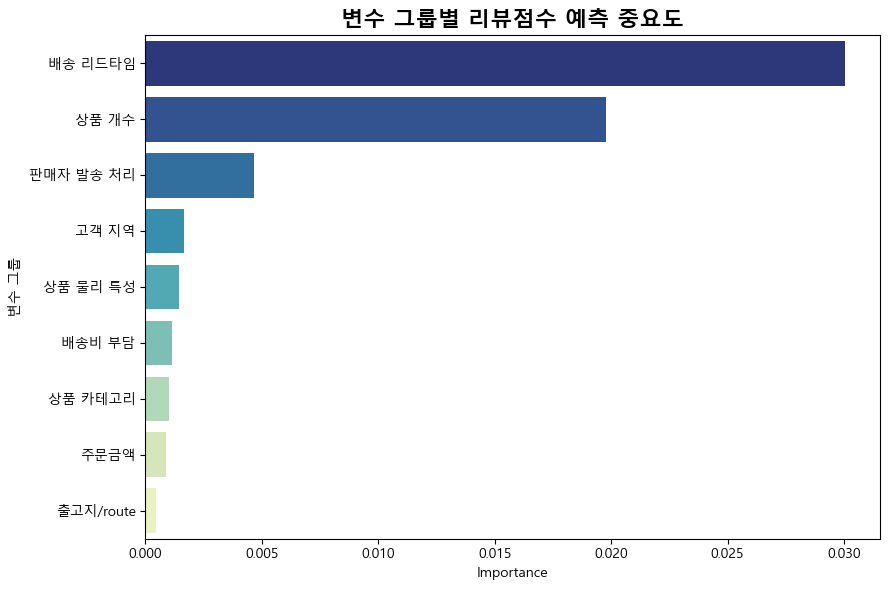

In [39]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=group_importance,
    y="feature_group",
    x="importance",
    palette="YlGnBu_r"
)

plt.title("변수 그룹별 리뷰점수 예측 중요도", fontsize=16, weight="bold")
plt.xlabel("Importance")
plt.ylabel("변수 그룹")

plt.tight_layout()
plt.show()

# 최종 해석 예시

판매자 정시 발송 + 정시 도착 주문과 판매자 지각 후 만회 + 정시 도착 주문의 리뷰점수 차이를 분석하기 위해 두 가지 모델을 비교하였다.

첫 번째 모델은 판매자 발송 지연 변수를 제외하고, 지역, 카테고리, 배송 리드타임, 주문 특성만으로 리뷰점수를 예측하였다.

이를 통해 두 집단의 점수 차이가 원래 배송이 오래 걸리는 지역이나 특정 카테고리, 다품목 주문, 배송비 부담 때문인지 확인하였다.

두 번째 모델은 판매자 발송 처리 변수를 포함하여 리뷰점수를 예측하였다.

만약 모델 2의 성능이 모델 1보다 개선되고, 변수 중요도에서 `seller_dispatch_days` 또는 `seller_late_to_carrier`가 높게 나타난다면, 최종 정시 도착 여부와 별개로 판매자 발송 처리 지연이 리뷰점수 하락에 영향을 줬을 가능성이 있다.

반대로 판매자 발송 처리 변수의 중요도가 낮고, 배송 리드타임, 카테고리, 지역, 배송비 부담의 중요도가 높다면, 두 집단의 점수 차이는 판매자 지연 자체보다 주문 구성과 배송 맥락의 차이에서 발생했을 가능성이 크다.

따라서 이 분석은 “판매자가 늦게 발송했지만 정시에 도착했는데도 왜 평점이 낮은가?”라는 질문에 대해, 판매자 처리 문제와 배송/상품/지역 맥락을 분리해서 해석하기 위한 탐색적 머신러닝 분석이다.